In [92]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

## Importante
Cambia esta variable a True si deseas guardar los graficos generados en formato .png

In [ ]:
guardar_graficos = False  # Cambia a False si no quieres guardar los gráficos   

# Experimento patron fijo

In [94]:
df_pat_fijo = pd.read_csv('exp_pat_fijo_results.csv', sep=';')

df_pat_fijo['filename'] = df_pat_fijo['text_path'].apply(lambda x: os.path.basename(x))

df_pat_fijo['percentage'] = df_pat_fijo['filename'].apply(lambda x: float(x.split(' ')[0]))

df_pat_fijo['text_type'] = df_pat_fijo['filename'].apply(lambda x: x.split(' ')[1])

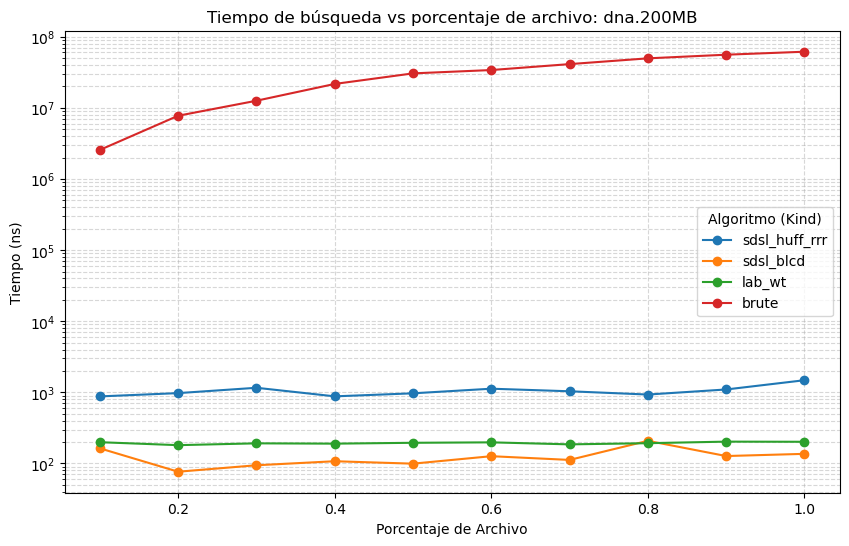

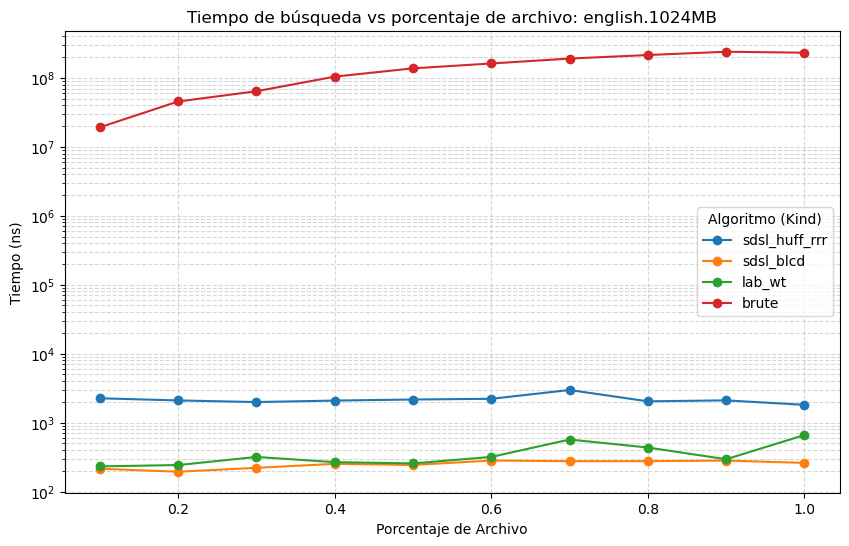

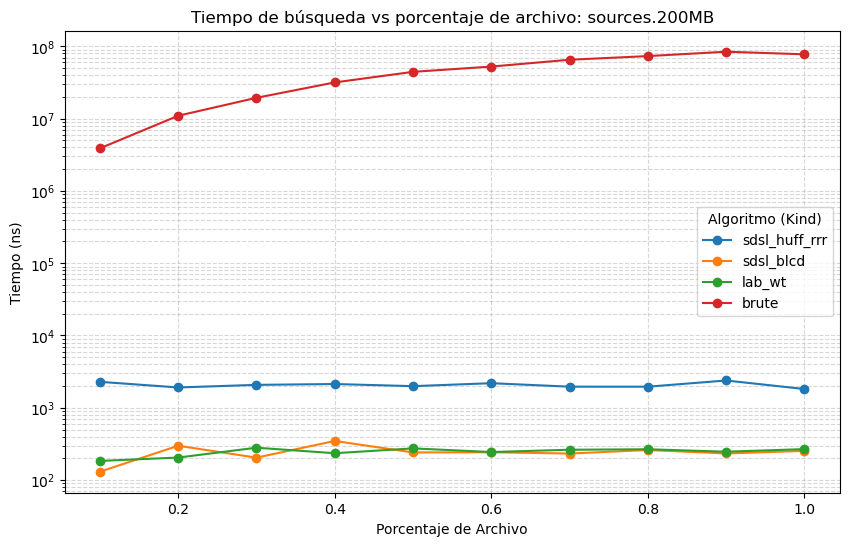

In [95]:

text_tipes = df_pat_fijo['text_type'].unique()
kinds = df_pat_fijo['kind'].unique()

for text_type in text_tipes:
    plt.figure(figsize=(10, 6)) 

    data_subset = df_pat_fijo[df_pat_fijo['text_type'] == text_type]

    for kind in kinds:
        subset = data_subset[data_subset['kind'] == kind]
        plt.plot(subset['percentage'], subset['time_ns'], marker='o', label=f'{kind}')
    plt.yscale('log')
    plt.xlabel('Porcentaje de Archivo')
    plt.ylabel('Tiempo (ns)')  
    plt.legend(title="Algoritmo (Kind)")
    plt.title(f'Tiempo de búsqueda vs porcentaje de archivo: {text_type}')
    plt.grid(True, which="both", linestyle='--', alpha=0.5)
    if guardar_graficos:
        plt.savefig(f'tiempo_pat_fijo_{text_type}.png', dpi=300)
plt.show()

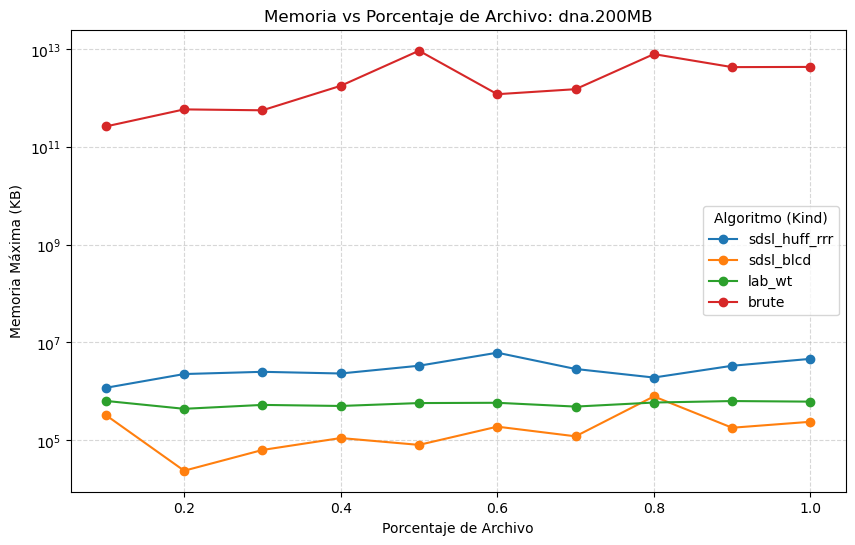

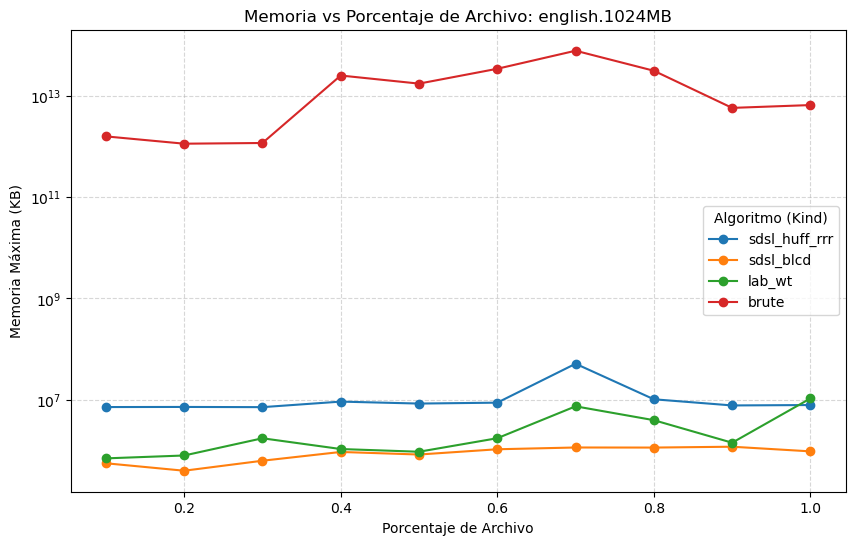

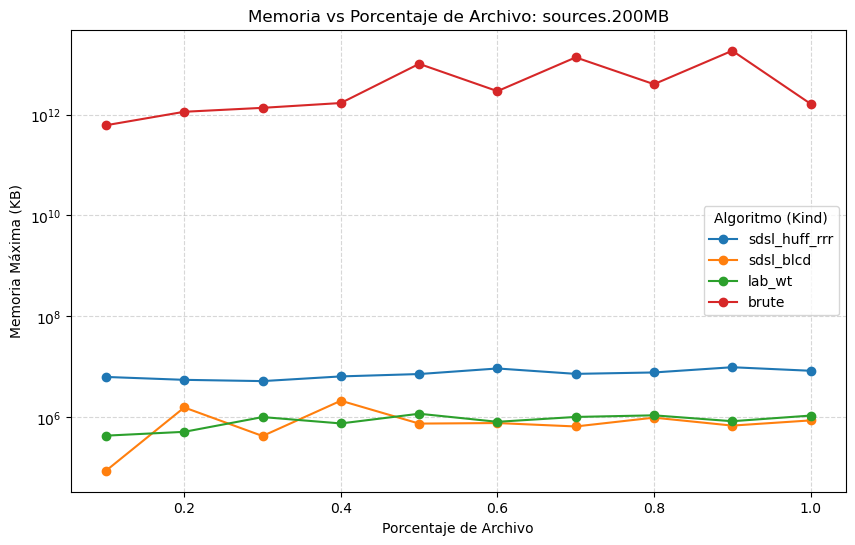

In [96]:
for text_type in text_tipes:
    plt.figure(figsize=(10, 6)) 

    data_subset = df_pat_fijo[df_pat_fijo['text_type'] == text_type]

    for kind in kinds:
        subset = data_subset[data_subset['kind'] == kind]
        plt.plot(subset['percentage'], subset['max_memory_kb'], marker='o', label=f'{kind}')
    plt.yscale('log')
    plt.xlabel('Porcentaje de Archivo')
    plt.ylabel('Memoria Máxima (KB)')
    plt.legend(title="Algoritmo (Kind)")
    plt.title(f'Memoria vs Porcentaje de Archivo: {text_type}')
    plt.grid(True, which="both", linestyle='--', alpha=0.5)
    if guardar_graficos:
        plt.savefig(f'memoria_pat_fijo_{text_type}.png', dpi=300)
plt.show()

# Experimentos para texto fijo

In [97]:
df_txt_fijo = pd.read_csv('exp_txt_fijo_results.csv', sep=';')
df_txt_fijo['filename'] = df_txt_fijo['text_path'].apply(lambda x: os.path.basename(x))
df_txt_fijo['filename']

0          dna.200MB
1          dna.200MB
2          dna.200MB
3          dna.200MB
4          dna.200MB
           ...      
211    sources.200MB
212    sources.200MB
213    sources.200MB
214    sources.200MB
215    sources.200MB
Name: filename, Length: 216, dtype: object

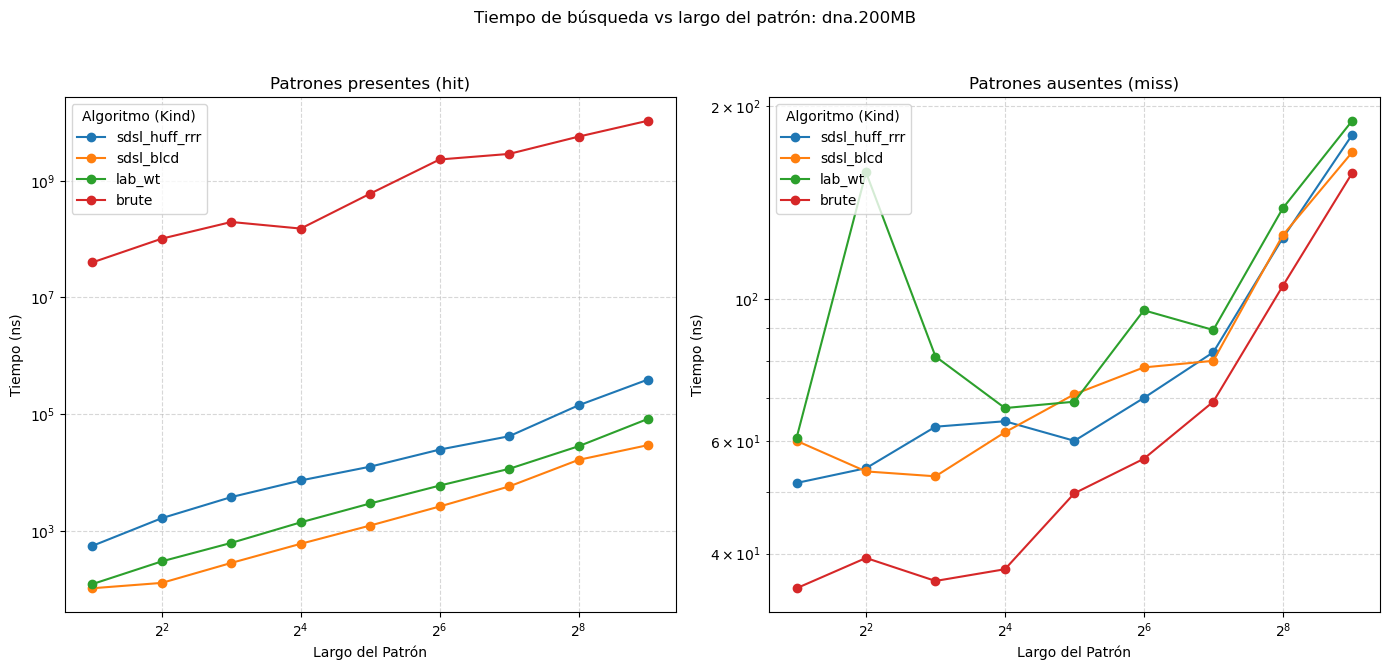

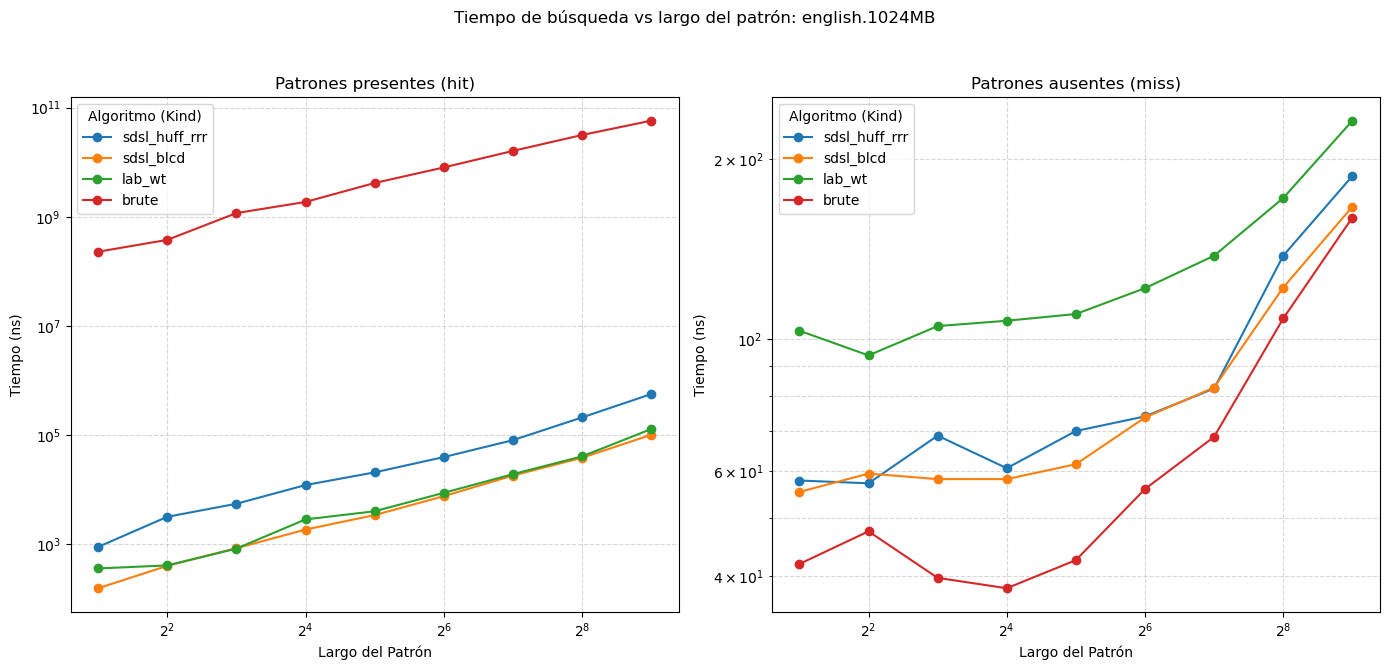

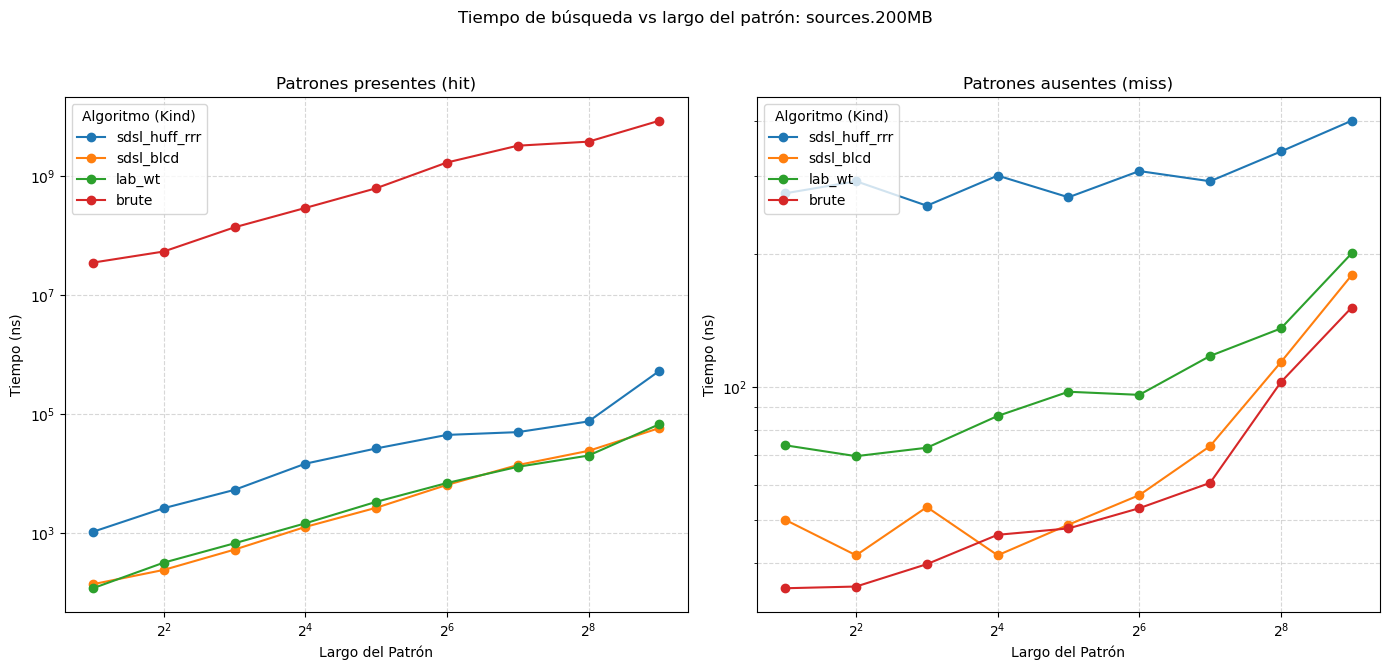

In [98]:
filenames = df_txt_fijo['filename'].unique()
kinds = df_txt_fijo['kind'].unique()
modes = df_txt_fijo['mode'].unique()

for filename in filenames:
    fig, axes = plt.subplots(1, 2, figsize=(14, 7))
    data_filename = df_txt_fijo[df_txt_fijo['filename'] == filename]

    for i, m in enumerate(modes):
        ax = axes[i]
        df_mode = data_filename[data_filename['mode'] == m]

        for kind in kinds:
            subset = df_mode[df_mode['kind'] == kind]
            ax.plot(subset['patt_size'], subset['time_ns'], marker='o', label=f'{kind}')
        ax.set_yscale('log')
        ax.set_xscale('log', base=2)
        ax.set_xlabel('Largo del Patrón')
        ax.set_ylabel('Tiempo (ns)')  
        ax.legend(title="Algoritmo (Kind)", loc='upper left')
        if m == 'hit':
            message = 'Patrones presentes (hit)'
        else:
            message = 'Patrones ausentes (miss)'
        ax.set_title(message)
        ax.grid(True, which="both", linestyle='--', alpha=0.5)
    plt.suptitle(f'Tiempo de búsqueda vs largo del patrón: {filename}')
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    if guardar_graficos:
        plt.savefig(f'tiempo_txt_fijo_{filename}.png', dpi=300)
plt.show()

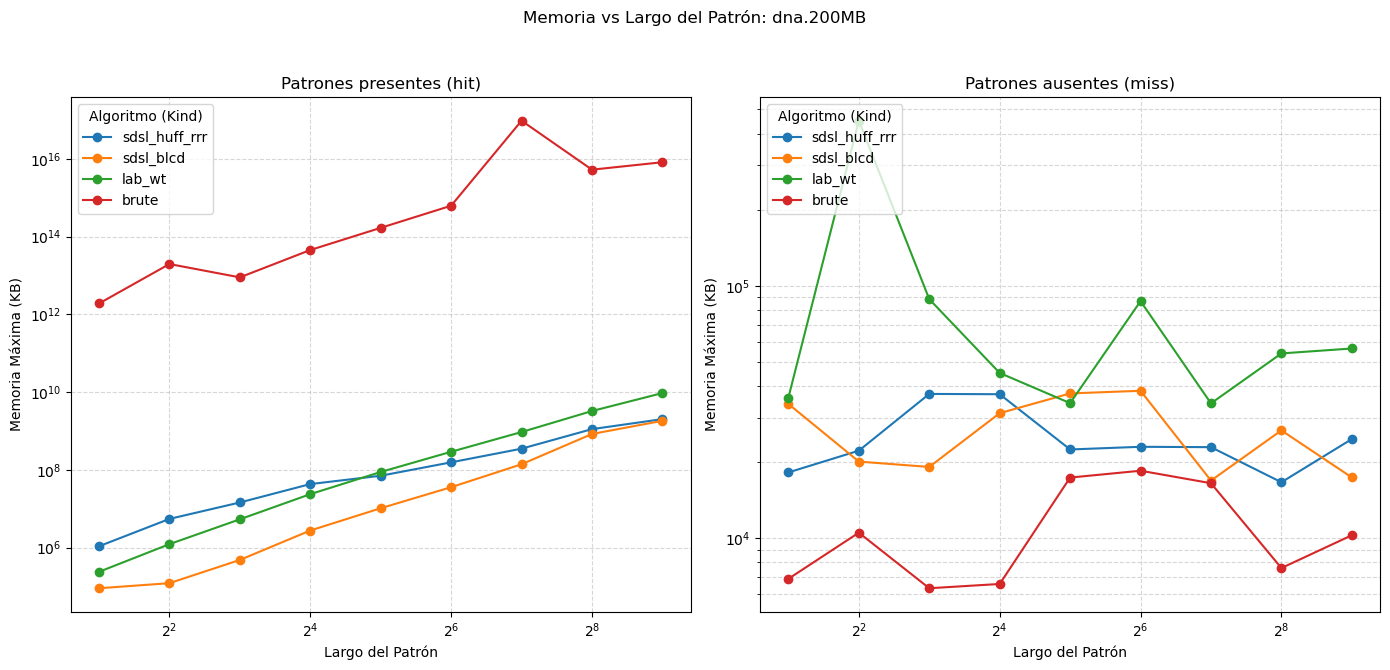

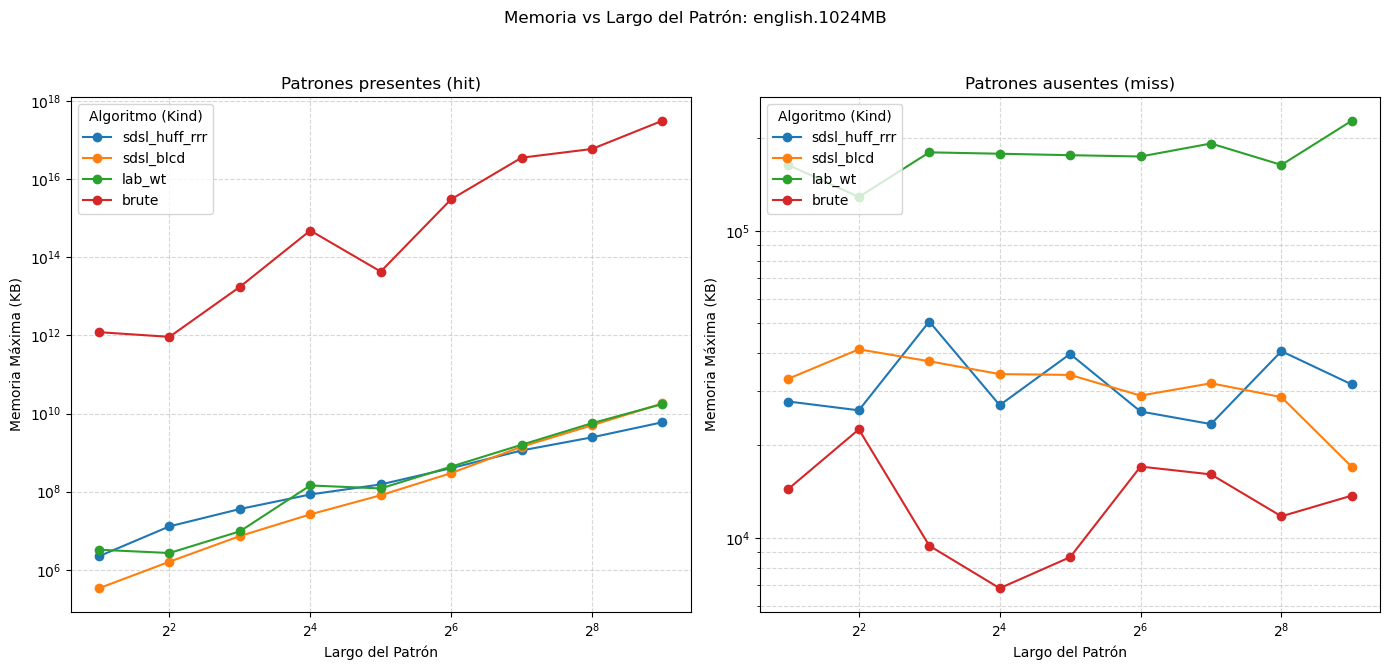

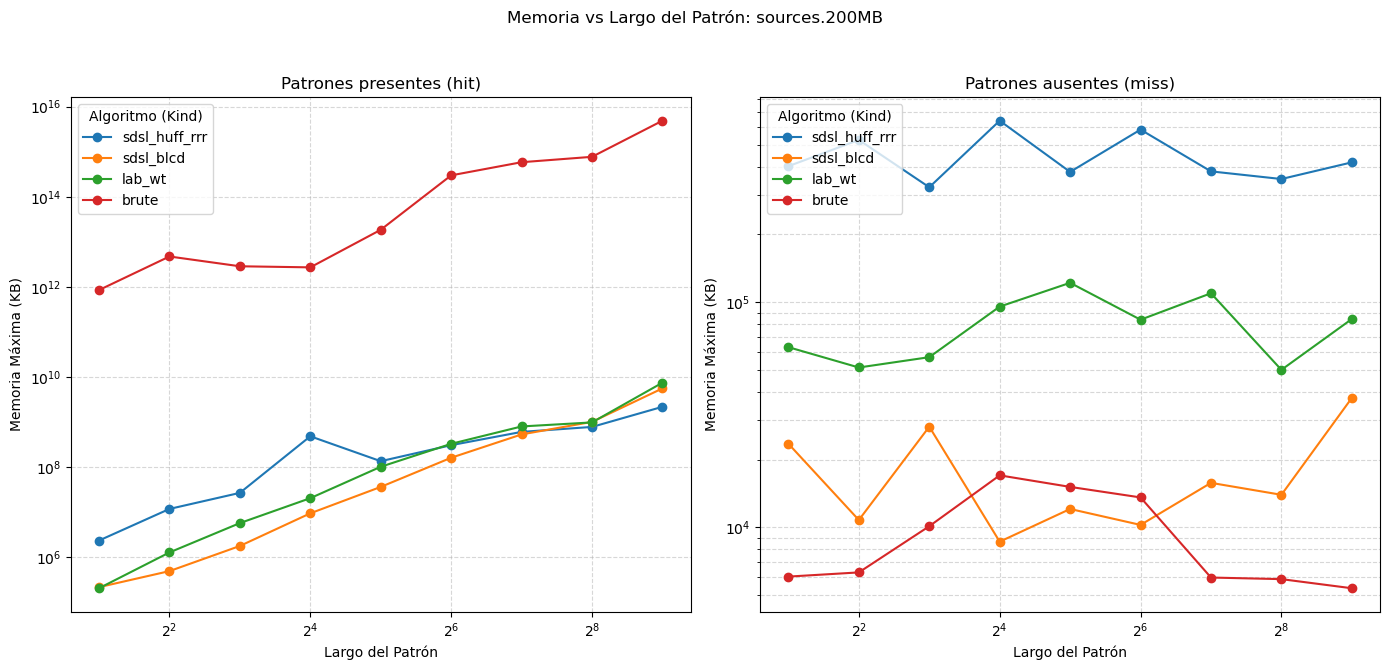

In [99]:
for filename in filenames:
    fig, axes = plt.subplots(1, 2, figsize=(14, 7))
    data_filename = df_txt_fijo[df_txt_fijo['filename'] == filename]

    for i, m in enumerate(modes):
        ax = axes[i]
        df_mode = data_filename[data_filename['mode'] == m]

        for kind in kinds:
            subset = df_mode[df_mode['kind'] == kind]
            ax.plot(subset['patt_size'], subset['max_memory_kb'], marker='o', label=f'{kind}')
        ax.set_yscale('log')
        ax.set_xscale('log', base=2)
        ax.set_xlabel('Largo del Patrón')
        ax.set_ylabel('Memoria Máxima (KB)')  
        ax.legend(title="Algoritmo (Kind)", loc='upper left')
        if m == 'hit':
            message = 'Patrones presentes (hit)'
        else:
            message = 'Patrones ausentes (miss)'
        ax.set_title(message)
        ax.grid(True, which="both", linestyle='--', alpha=0.5)
    plt.suptitle(f'Memoria vs Largo del Patrón: {filename}')
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    if guardar_graficos:
        plt.savefig(f'memoria_txt_fijo_{filename}.png', dpi=300)
plt.show()